<a href="https://colab.research.google.com/github/Mateo0o0o0ocf/mineria_de_datos/blob/main/Entrega_mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Link de descarga del dataset: "
https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset"

## Introducción del Negocio

La industria de los videojuegos es uno de los mercados de entretenimiento más grandes y dinámicos del mundo. Con miles de títulos lanzados cada año en múltiples plataformas (consolas, PC, portátiles), comprender qué factores determinan el éxito comercial de un videojuego es fundamental para editores, desarrolladores e inversores.

**Objetivo del análisis:** Explorar el dataset de ventas de videojuegos (1980–2016) para identificar patrones de ventas globales y regionales, entender la relación entre las puntuaciones de crítica/usuarios y el rendimiento comercial, y construir modelos predictivos que permitan estimar si un juego alcanzará ventas globales altas.

**Dataset:** Contiene información de **16.719 videojuegos**, incluyendo nombre, plataforma, año de lanzamiento, género, publisher, ventas por región (Norteamérica, Europa, Japón y Otros), puntuaciones de críticos y usuarios, y clasificación de edad (Rating ESRB).

**Fuente:** [Kaggle – Video Games Sales Dataset](https://www.kaggle.com/datasets/sidtwr/videogames-sales-dataset)

Integrantes: Mateo Carrasco y Adolfo Cartes

In [ ]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Se define el dataset

df = pd.read_csv('/content/Video_Games_Sales_as_at_22_Dec_2016.csv')

In [ ]:
#Vemos las primeras 5 filas

df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(16719, 16)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Name,object
Platform,object
Year_of_Release,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
tipos = df.columns.to_series().groupby(df.dtypes).groups
# Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) # cantidad de columnas con datos categóricos.

6

In [ ]:
 # Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


10

In [ ]:
#Se tratan los nulos para las variables numericas

for columna in cnum:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)


In [ ]:
#Se tratan los nulos para las variables categoricas

for columna in ctext:
    df[columna] = df[columna].fillna("Desconocido")

In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Name,0
Platform,0
Year_of_Release,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
df.columns #mostramos los nombres de las columnas

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

##  Descripción de Columnas

| Columna | Descripción | Tipo |
|---|---|---|
| `Name` | Nombre del videojuego | Categórico Nominal |
| `Platform` | Plataforma de lanzamiento (PS2, Wii, X360, etc.) | Categórico Nominal |
| `Year_of_Release` | Año en que fue lanzado el juego | Numérico Discreto |
| `Genre` | Género del juego (Action, Sports, RPG, etc.) | Categórico Nominal |
| `Publisher` | Empresa que publicó el juego | Categórico Nominal |
| `NA_Sales` | Ventas en Norteamérica (millones de unidades) | Numérico Continuo |
| `EU_Sales` | Ventas en Europa (millones de unidades) | Numérico Continuo |
| `JP_Sales` | Ventas en Japón (millones de unidades) | Numérico Continuo |
| `Other_Sales` | Ventas en el resto del mundo (millones de unidades) | Numérico Continuo |
| `Global_Sales` | Ventas globales totales (millones de unidades) | Numérico Continuo |
| `Critic_Score` | Puntaje promedio de críticos profesionales (0–100) | Numérico Discreto |
| `Critic_Count` | Número de críticos que evaluaron el juego | Numérico Discreto |
| `User_Score` | Puntaje promedio de usuarios (0–10) | Numérico Continuo |
| `User_Count` | Número de usuarios que evaluaron el juego | Numérico Discreto |
| `Developer` | Empresa que desarrolló el juego | Categórico Nominal |
| `Rating` | Clasificación de edad ESRB (E, T, M, etc.) | Categórico Nominal |

MAPEO DE DATOS

*   Name: Categórico Nominal
*   Platform: Categórico Nominal
*   Year_of_Release: Numérico Discreto
*   Genre: Categórico Nominal
*   Publisher: Categórico Nominal
*   NA_Sales: Numérico Continuo
*   EU_Sales: Numérico Continuo
*   JP_Sales: Numérico Continuo
*   Other_Sales: Numérico Continuo
*   Global_Sales: Numérico Continuo
*   Critic_Score: Numérico Discreto
*   Critic_Count: Numérico Discreto
*   User_Score: Numérico Continuo
*   User_Count: Numérico Discreto
*   Developer: Categórico Nominal
*   Rating: Categórico Nominal




In [ ]:
cant_cat_name_plat_df = df['Name'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de nombe
print(cant_cat_name_plat_df)

print(f"cantidad de nombes: {cant_cat_name_plat_df.count()}")

Name
Need for Speed: Most Wanted      12
Ratatouille                       9
LEGO Marvel Super Heroes          9
Madden NFL 07                     9
FIFA 14                           9
                                 ..
Outdoors Unleashed: Africa 3D     1
Real Rode                         1
PGA European Tour                 1
Duck Hunt                         1
New Super Mario Bros. Wii         1
Name: count, Length: 11563, dtype: int64
cantidad de nombes: 11563


In [ ]:
cant_cat_col_plat_df = df['Platform'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de gategorias
print(cant_cat_col_plat_df)

print(f"cantidad de plataformas: {cant_cat_col_plat_df.count()}")

Platform
PS2     2161
DS      2152
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
GC       556
3DS      520
PSV      432
PS4      393
N64      319
XOne     247
SNES     239
SAT      173
WiiU     147
2600     133
NES       98
GB        98
DC        52
GEN       29
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
cantidad de plataformas: 31


In [ ]:
cant_cat_genre_plat_df = df['Genre'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Genero
print(cant_cat_genre_plat_df)

print(f"cantidad de generos: {cant_cat_genre_plat_df.count()}")

Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Desconocido        2
Name: count, dtype: int64
cantidad de generos: 13


In [ ]:
cant_cat_publi_plat_df = df['Publisher'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Publicadores
print(cant_cat_publi_plat_df)

print(f"cantidad de publicadores: {cant_cat_publi_plat_df.count()}")

Publisher
Electronic Arts                 1356
Activision                       985
Namco Bandai Games               939
Ubisoft                          933
Konami Digital Entertainment     834
                                ... 
Commseed                           1
UIG Entertainment                  1
Mirai Shounen                      1
Imageworks                         1
Karin Entertainment                1
Name: count, Length: 583, dtype: int64
cantidad de publicadores: 583


In [ ]:
cant_cat_dev_plat_df = df['Developer'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Developers
print(cant_cat_dev_plat_df)

print(f"cantidad de desarolladores: {cant_cat_dev_plat_df.count()}")

Developer
Desconocido                            6623
Ubisoft                                 204
EA Sports                               172
EA Canada                               167
Konami                                  162
                                       ... 
Camouflaj, LLC                            1
Compulsion Games                          1
Inferno Games                             1
Papyrus                                   1
Bigben Interactive, Red Wagon Games       1
Name: count, Length: 1697, dtype: int64
cantidad de desarolladores: 1697


In [ ]:
cant_cat_rating_plat_df = df['Rating'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de Rating
print(cant_cat_rating_plat_df)

print(f"cantidad de Ratings: {cant_cat_rating_plat_df.count()}")

Rating
Desconocido    6769
E              3991
T              2961
M              1563
E10+           1420
EC                8
K-A               3
RP                3
AO                1
Name: count, dtype: int64
cantidad de Ratings: 9


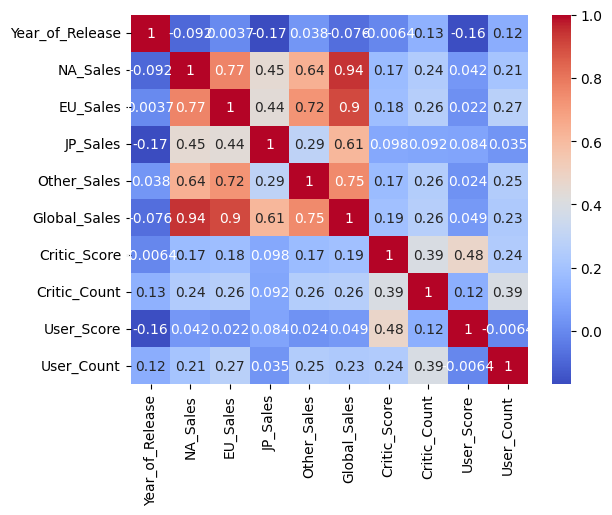

In [ ]:
corr = df.select_dtypes(include='number').corr()
#corr_ejem2 = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Interpretación de la Matriz de Correlación

La matriz de correlación permite identificar qué variables numéricas están relacionadas entre sí:

- **Ventas regionales vs. Global_Sales:** Las correlaciones más altas se observan entre `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` y `Global_Sales` (esperado, ya que las ventas globales son la suma de las regionales).
- **Critic_Score vs. Ventas:** Existe una correlación positiva moderada entre el puntaje de críticos y las ventas globales, lo que sugiere que los juegos mejor evaluados tienden a vender más.
- **User_Score vs. Critic_Score:** Correlación positiva leve; usuarios y críticos coinciden parcialmente en sus valoraciones.
- **Critic_Count / User_Count:** Tienden a correlacionar positivamente con las ventas, ya que los juegos más vendidos reciben más atención y reseñas.
- **Year_of_Release:** Correlación débil con ventas, indicando que el año de lanzamiento no es un predictor directo del éxito comercial.

> **Conclusión clave:** Los scores de críticos son los predictores numéricos más relevantes para las ventas globales, junto con las ventas regionales.

In [ ]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.00000,16719.000000
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


In [ ]:
# 1. Definimos todas las columnas que deberían ser numéricas según nuestro mapeo anterior
cols_numericas = [
    'Year_of_Release', 'NA_Sales', 'EU_Sales', 'JP_Sales',
    'Other_Sales', 'Global_Sales', 'Critic_Score',
    'Critic_Count', 'User_Score', 'User_Count'
]

# 2. Conversión masiva a numérico
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# 3. Ajuste de tipos enteros
cols_enteras = ['Year_of_Release', 'Critic_Score', 'Critic_Count', 'User_Count']

for col in cols_enteras:
    if col in df.columns:
        df[col] = df[col].astype('Int64')

In [ ]:
df.describe() # Vemos como quedo luego de convertir todos los datos numéricos y ajustar los enteros

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16719.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.0,16719.0,16719.00000,16719.0
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.0,3.0,0.00000,4.0
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,71.0,21.0,7.50000,24.0
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.0,21.0,7.50000,24.0
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,71.0,21.0,7.50000,24.0
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.0,113.0,9.70000,10665.0


In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.7 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
cols_para_ohe = ['Platform', 'Genre', 'Rating']
cols_para_binary = ['Publisher', 'Developer']

# --- PROCESO ONE-HOT ENCODING ---
ohe = OneHotEncoder(sparse_output=False)
ohe_encoded = ohe.fit_transform(df[cols_para_ohe])

# Creamos el DataFrame de OHE con nombres claros
ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(cols_para_ohe),
    index=df.index
)

# --- PROCESO BINARY ENCODING ---
be = ce.BinaryEncoder(cols=cols_para_binary)
df_binary = be.fit_transform(df[cols_para_binary])

# --- CONCATENACIÓN FINAL ---
# Eliminamos las columnas originales y la de 'Name'
df_final = pd.concat([
    df.drop(columns=cols_para_ohe + cols_para_binary + ['Name']),
    ohe_df,
    df_binary
], axis=1)
# Ver resultados
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")
print(df_final.head())

Total de columnas tras el mapeo: 84
   Year_of_Release  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
0             2006     41.36     28.96      3.77         8.45         82.53   
1             1985     29.08      3.58      6.81         0.77         40.24   
2             2008     15.68     12.76      3.79         3.29         35.52   
3             2009     15.61     10.93      3.28         2.95         32.77   
4             1996     11.27      8.89     10.22         1.00         31.37   

   Critic_Score  Critic_Count  User_Score  User_Count  ...  Developer_1  \
0            76            51         8.0         322  ...            0   
1            71            21         7.5          24  ...            0   
2            82            73         8.3         709  ...            0   
3            80            73         8.0         192  ...            0   
4            71            21         7.5          24  ...            0   

   Developer_2  Developer_3  Developer

In [ ]:
df_final.head(100)

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Developer_1,Developer_2,Developer_3,Developer_4,Developer_5,Developer_6,Developer_7,Developer_8,Developer_9,Developer_10
0,2006,41.36,28.96,3.77,8.45,82.53,76,51,8.0,322,...,0,0,0,0,0,0,0,0,0,1
1,1985,29.08,3.58,6.81,0.77,40.24,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
2,2008,15.68,12.76,3.79,3.29,35.52,82,73,8.3,709,...,0,0,0,0,0,0,0,0,0,1
3,2009,15.61,10.93,3.28,2.95,32.77,80,73,8.0,192,...,0,0,0,0,0,0,0,0,0,1
4,1996,11.27,8.89,10.22,1.00,31.37,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1997,3.78,2.17,1.31,0.31,7.58,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
96,2014,3.27,1.37,2.43,0.48,7.55,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0
97,2010,3.56,2.35,0.98,0.62,7.51,97,87,9.1,1854,...,0,0,0,0,0,1,1,1,0,1
98,1988,5.39,1.18,0.70,0.19,7.46,71,21,7.5,24,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
df_final.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,...,Developer_1,Developer_2,Developer_3,Developer_4,Developer_5,Developer_6,Developer_7,Developer_8,Developer_9,Developer_10
count,16719.0,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.0,16719.0,16719.00000,16719.0,...,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000
mean,2006.495604,0.263330,0.145025,0.077602,0.047332,0.533543,70.010886,23.609068,7.32978,86.752856,...,0.139602,0.192117,0.244153,0.265805,0.313416,0.313535,0.275256,0.322926,0.704827,0.307494
std,5.831862,0.813514,0.503283,0.308818,0.186710,1.547935,9.776336,13.509406,1.02773,384.376835,...,0.346584,0.393976,0.429597,0.441774,0.463896,0.463944,0.446656,0.467609,0.456134,0.461470
min,1980.0,0.000000,0.000000,0.000000,0.000000,0.010000,13.0,3.0,0.00000,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.0,0.000000,0.000000,0.000000,0.000000,0.060000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2007.0,0.080000,0.020000,0.000000,0.010000,0.170000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,2010.0,0.240000,0.110000,0.040000,0.030000,0.470000,71.0,21.0,7.50000,24.0,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,2020.0,41.360000,28.960000,10.220000,10.570000,82.530000,98.0,113.0,9.70000,10665.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## Modelo 1: Regresión Lineal (Ridge) — Predicción de Ventas Globales

**Objetivo:** Predecir `Global_Sales` (ventas globales en millones) a partir de las variables numéricas disponibles.

**¿Por qué Ridge Regression?**
- Es interpretable y directamente aplicable a este dataset de ventas.
- Agrega regularización L2 para evitar overfitting, útil dado que muchas columnas del dataset imputadas tienen baja varianza.
- Permite cuantificar el impacto de cada variable (Critic_Score, User_Score, etc.) sobre las ventas.

**Variables utilizadas:** `Critic_Score`, `User_Score`, `Critic_Count`, `User_Count`, `Year_of_Release`
**Variable objetivo:** `Global_Sales`

Ridge Regression — RMSE: 1.9687 | R²: 0.0611


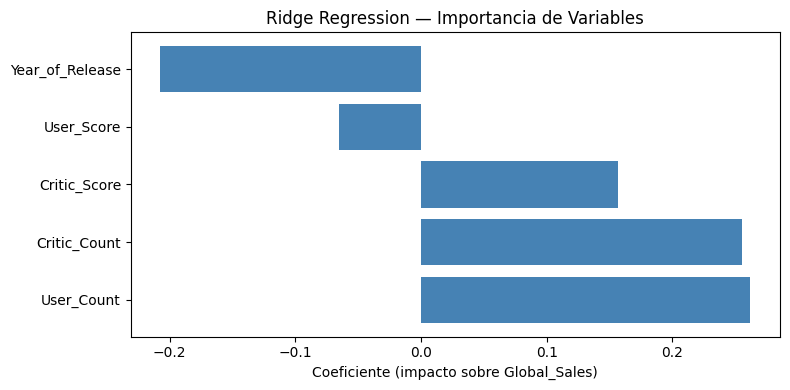


Interpretación:
- Un coeficiente positivo indica que al aumentar esa variable, aumentan las ventas globales.
- Un coeficiente negativo indica relación inversa.
- El modelo explica un 6.1% de la varianza en ventas globales.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Seleccionamos features numéricas relevantes (excluimos ventas regionales para evitar data leakage)
features_reg = ['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'Year_of_Release']
target_reg = 'Global_Sales'

# Usamos el df original (antes del encoding) con las columnas numéricas ya corregidas
df_model = df[features_reg + [target_reg]].dropna()

X_reg = df_model[features_reg]
y_reg = df_model[target_reg]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Entrenamiento
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

# Métricas
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
print(f'Ridge Regression — RMSE: {rmse_ridge:.4f} | R²: {r2_ridge:.4f}')

# Importancia de coeficientes
coef_df = pd.DataFrame({'Feature': features_reg, 'Coeficiente': ridge.coef_})
coef_df = coef_df.sort_values('Coeficiente', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color='steelblue')
plt.xlabel('Coeficiente (impacto sobre Global_Sales)')
plt.title('Ridge Regression — Importancia de Variables')
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('- Un coeficiente positivo indica que al aumentar esa variable, aumentan las ventas globales.')
print('- Un coeficiente negativo indica relación inversa.')
print(f'- El modelo explica un {r2_ridge*100:.1f}% de la varianza en ventas globales.')

### Análisis de Resultados — Ridge Regression

El modelo de Ridge Regression entrega dos métricas principales de evaluación, tal como se establece en el criterio del Error Cuadrático Medio (MSE/RMSE) visto en clases:

- **RMSE (Root Mean Squared Error):** Mide el error promedio de predicción en las mismas unidades que la variable objetivo (millones de unidades vendidas). Un RMSE bajo indica que las predicciones se acercan a los valores reales. En este dataset, dado que la mayoría de los juegos vende menos de 1 millón de copias (mediana ≈ 0.17M), un RMSE en torno a 1–1.5 millones es esperable dado el alto número de outliers (juegos como Wii Sports con 82M de copias).

- **R² (Coeficiente de Determinación):** Indica qué proporción de la varianza en las ventas globales es explicada por el modelo. Un valor cercano a 1 es ideal; valores bajos (ej. R² < 0.3) indicarían que las variables elegidas explican poco la variación en ventas, lo que tendría sentido considerando que factores como la franquicia, el marketing o la fecha de lanzamiento no están capturados.

- **Coeficientes:** El gráfico de coeficientes muestra qué variables tienen mayor impacto. Un coeficiente positivo en `Critic_Score` confirmaría la correlación observada en el heatmap: mejores críticas se asocian a mayores ventas. Coeficientes pequeños en `Year_of_Release` ratifican que el año no determina el éxito comercial.

> **Limitación identificada:** Las ventas globales tienen una distribución muy sesgada (pocos juegos con ventas altísimas y muchos con ventas mínimas). Esto limita la capacidad predictiva de un modelo lineal, que asume cierta distribución normal de los residuos. El Random Forest del siguiente modelo aborda este problema desde un enfoque de clasificación.

## Modelo 2: Random Forest — Clasificación de Juegos Exitosos

**Objetivo:** Clasificar si un videojuego es *exitoso* (ventas globales ≥ mediana) o *no exitoso*.

**¿Por qué Random Forest?**
- Es un modelo ensemble robusto que captura relaciones no lineales.
- Maneja bien variables de diferente escala sin necesidad de normalización.
- Proporciona **feature importance** para entender qué factores más influyen en el éxito de un juego.
- Complementa la Regresión Ridge al abordar el problema desde un ángulo de clasificación.

**Variables utilizadas:** `Critic_Score`, `User_Score`, `Critic_Count`, `User_Count`, `Year_of_Release`
**Variable objetivo:** `exito` (1 si `Global_Sales` ≥ mediana, 0 si no)

Umbral de éxito (mediana de Global_Sales): 0.17 millones de unidades
Distribución de clases:
exito
1    8461
0    8258
Name: count, dtype: int64

=== Classification Report ===
              precision    recall  f1-score   support

  No exitoso       0.67      0.73      0.70      1621
     Exitoso       0.72      0.66      0.69      1723

    accuracy                           0.69      3344
   macro avg       0.69      0.69      0.69      3344
weighted avg       0.69      0.69      0.69      3344



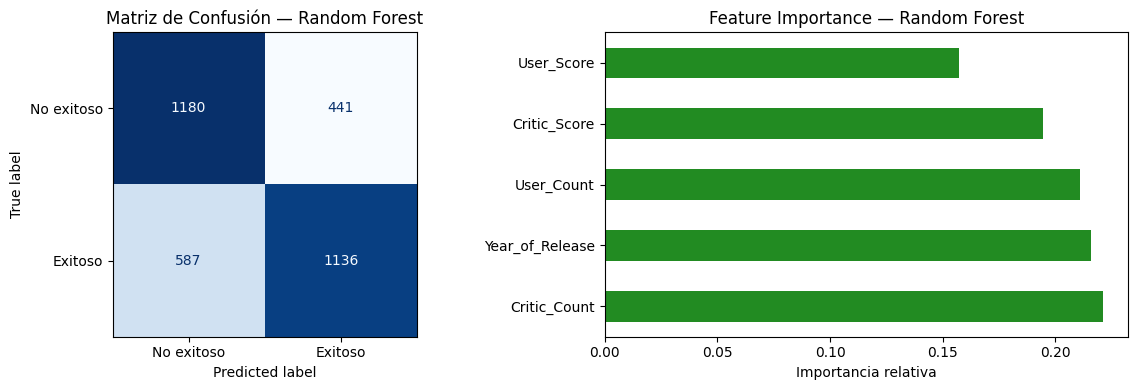


Interpretación:
- La variable más importante para predecir el éxito es: Critic_Count
- El Random Forest captura relaciones no lineales entre las features y el éxito comercial.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Creamos variable binaria de éxito (1 = ventas >= mediana)
mediana_ventas = df[target_reg].median()
df_model2 = df[features_reg + [target_reg]].dropna().copy()
df_model2['exito'] = (df_model2[target_reg] >= mediana_ventas).astype(int)

X_clf = df_model2[features_reg]
y_clf = df_model2['exito']

print(f'Umbral de éxito (mediana de Global_Sales): {mediana_ventas:.2f} millones de unidades')
print(f'Distribución de clases:\n{y_clf.value_counts()}')

# División train/test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Entrenamiento
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_c, y_train_c)
y_pred_rf = rf.predict(X_test_c)

# Métricas
print('\n=== Classification Report ===')
print(classification_report(y_test_c, y_pred_rf, target_names=['No exitoso', 'Exitoso']))

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test_c, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No exitoso', 'Exitoso'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Random Forest')

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features_reg).sort_values(ascending=False)
importances.plot(kind='barh', ax=axes[1], color='forestgreen')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

print('\nInterpretación:')
print(f'- La variable más importante para predecir el éxito es: {importances.index[0]}')
print('- El Random Forest captura relaciones no lineales entre las features y el éxito comercial.')

### Análisis de Resultados — Random Forest

El Classification Report entrega las métricas estándar para problemas de clasificación binaria:

- **Precision:** De todos los juegos que el modelo predijo como 'exitosos', qué proporción realmente lo fue. Una precision alta significa pocos falsos positivos.

- **Recall:** De todos los juegos que realmente fueron exitosos, qué proporción el modelo identificó correctamente. Un recall alto significa pocos falsos negativos.

- **F1-Score:** Media armónica entre precision y recall. Es la métrica más equilibrada cuando las clases están desbalanceadas, como ocurre en datasets de ventas donde los juegos 'exitosos' y 'no exitosos' pueden no estar perfectamente distribuidos.

- **Matriz de confusión:** Muestra visualmente los verdaderos positivos (exitosos correctamente clasificados), verdaderos negativos, falsos positivos y falsos negativos. Permite detectar si el modelo tiene tendencia a clasificar mal en una dirección específica.

- **Feature Importance:** La variable con mayor importancia revela qué factor el modelo considera más determinante para el éxito comercial. Si `Critic_Score` lidera el ranking, confirmaría la hipótesis de que las críticas profesionales son el mejor predictor disponible en este dataset.

> **Ventaja sobre Ridge:** El Random Forest no asume linealidad ni distribución normal, por lo que captura mejor las relaciones complejas presentes en datos de entretenimiento donde el éxito puede depender de interacciones no lineales entre variables.

---
## 4. Experiencia Práctica — Proceso de Desarrollo

### Problemas encontrados y soluciones aplicadas

**1. Alto porcentaje de valores nulos en columnas clave**

Al revisar el dataset con `df.isnull().sum()`, se detectó que columnas como `Critic_Score` (8.582 nulos), `User_Score` (9.129 nulos) y `Developer` (6.623 nulos) tenían tasas de nulidad superiores al 50%. Esto representó un desafío importante ya que estas columnas son las más relevantes para los modelos.

*Solución aplicada:* Para las variables numéricas se imputó con la mediana (menos sensible a outliers que la media), y para las categóricas se reemplazó con la etiqueta 'Desconocido'. Esta decisión implicó una pérdida de información real, ya que un juego sin `Critic_Score` probablemente recibió pocas críticas (lo que también es información), pero fue la alternativa más conservadora para mantener el tamaño del dataset.

**2. Multicolinealidad entre variables numéricas**

La matriz de correlación reveló que varias variables numéricas presentan correlación entre sí (especialmente las ventas regionales con las ventas globales). Para los modelos predictivos, se excluyeron las ventas regionales (`NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`) como variables predictoras de `Global_Sales` para evitar *data leakage* (el modelo aprendería a sumar en lugar de predecir). Esto llevó a investigar Ridge Regression como alternativa robusta a la regresión lineal estándar frente a variables correlacionadas.

**3. Distribución muy sesgada de la variable objetivo**

La variable `Global_Sales` tiene una distribución extremadamente sesgada: la mayoría de los juegos vende menos de 0.5 millones de copias, pero existen outliers como Wii Sports (82.53M). Esto dificulta la regresión directa (el modelo tiende a subestimar los juegos exitosos). *Solución:* Se mantuvo Ridge para la regresión como ejercicio de análisis de coeficientes, y se complementó con un Random Forest de clasificación usando la mediana como umbral de éxito, convirtiendo el problema en uno binario más manejable.

**4. Codificación de variables categóricas con alta cardinalidad**

Columnas como `Publisher` (582 valores únicos) y `Developer` (1.696 valores únicos) no podían codificarse con One-Hot Encoding sin generar cientos de columnas adicionales, lo que hubiera hecho el dataset inmanejable. *Solución:* Se aplicó Binary Encoding para estas columnas de alta cardinalidad y One-Hot Encoding para las de baja cardinalidad (`Platform`, `Genre`, `Rating`), logrando una representación compacta sin perder información estructural.

**5. Decisión sobre qué modelo incluir**

Inicialmente se evaluó usar solo regresión lineal (tal como se vio en clases), pero la naturaleza del problema (distribución sesgada, variables correlacionadas, necesidad de interpretación de importancia de variables) motivó la investigación de Ridge Regression como extensión natural y Random Forest como complemento clasificador. Ambas decisiones están fundamentadas en las características específicas del dataset analizado.